In [1]:
# plan:
# for each timestep:
#     load training data
#     load test data
#     project
#     for each sigma:
#         for each kernel:
#             smoothen
#             build ROM
#             sharpen
#             calculate test error
#     load validation data
#     calculate validation error
# box plot error over time
# plot sigma over time
# plot k_s over time

In [2]:
import numpy as np
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
from matplotlib.colors import rgb2hex
from mpl_toolkits.axes_grid1 import make_axes_locatable
from ezyrb import POD, RBF, Database, Linear, RegularGrid
from ezyrb import ReducedOrderModel as ROM
from scipy.interpolate import griddata
from datetime import datetime
from smooth_POD_ROM.pre_processing import (
    on_regular_grid, _gauss_2d, to_frequency, to_space, add_padding)
from smooth_POD_ROM.post_processing import sharpen
#from smooth_POD_ROM.io import get_data, get_field
#from smooth_POD_ROM.plotting import plot_mesh, plot_field, plot_structured_field
from copy import deepcopy
from scipy.ndimage import gaussian_filter
from scipy.fft import fft2, ifft2, fftshift, ifftshift
from scipy.signal import wiener, convolve2d
from skimage import restoration
from skimage.restoration import richardson_lucy
#import tvtk
import vtk
from vtk.util.numpy_support import vtk_to_numpy
import cv2
from datetime import datetime
from os import listdir
from os.path import isfile, join
import re

In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl
cmap = plt.cm.viridis_r
#cmap.set_over('red')

page_width_pt = 455.24
pt2in = 0.01389 
pt2cm = 0.0352777778
cm2in = 1/2.54
page_width_cm = 13.70499
# TODO: work with textwidth
plot_width_in = page_width_pt*pt2in/2
page_width_in = page_width_cm*cm2in
print(plot_width_in/cm2in)

fs = 10
fs_lbl = 6
plt.rcParams["figure.figsize"] = (page_width_in/2, page_width_in/3)
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = fs
plt.rcParams['axes.titlesize'] = fs
plt.rcParams['axes.labelsize'] = fs
plt.rcParams['xtick.labelsize'] = fs
plt.rcParams['ytick.labelsize'] = fs
plt.rcParams['legend.labelspacing'] = 0.0
plt.rcParams['legend.fontsize'] = fs_lbl
plt.rcParams['legend.handlelength'] = 1.0

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=fs, serif='Computer Modern Roman')
pth = "../Plots/"

markevery = 25

8.030570172000001


In [4]:
pth_very_old_simulation_results = "C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/data/damBreak_results/"
pth_server_dbCoarseVTU = "//files.ad.ife.no/MatPro_files/Florian/damBreak_results/"
pth_server_dbFineVTU = "//files.ad.ife.no/MatPro_files/Florian/damBreak_results_Finemesh2/"

pth_local_dbCoarseOLD = "C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/data/DamBreak/"
pth_local_dbFineOLD = "C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/data/DamBreak2/"
pth_local_dbCoarse = "C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/data/DamBreakCoarse/"
pth_local_dbFine = "C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/data/DamBreakFine/"
rank = 80
size_p_test = 20
timestep = 0.25
apply_threshold = False

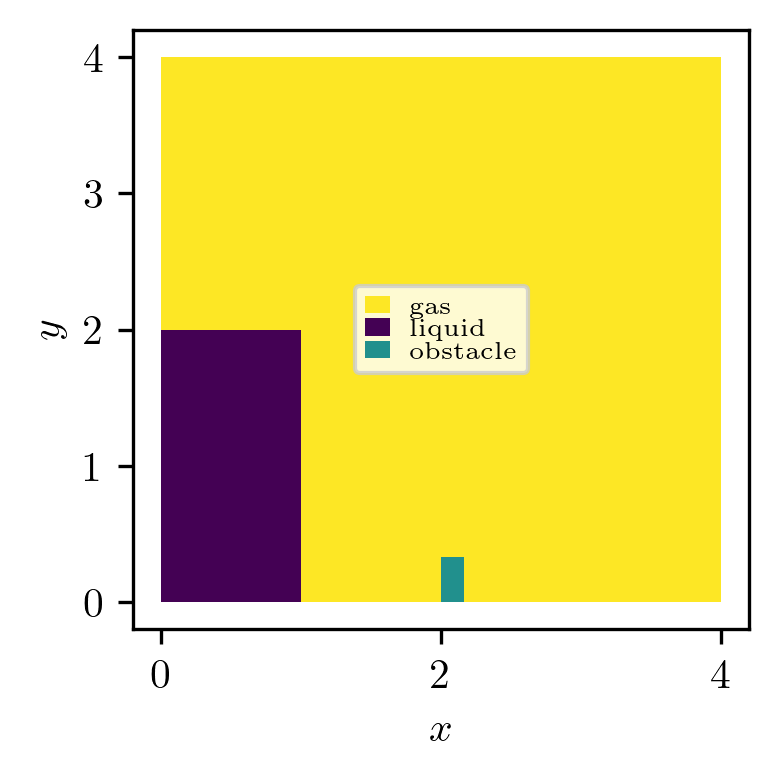

In [5]:
domain = np.array([
    [0, 0, 0],
    [2, 0, 0],
    [2, 0.32876, 0],
    [2.16438, 0.32876, 0],
    [2.16438, 0, 0],
    [4, 0, 0],
    [4, 4, 0],
    [0, 4, 0],
])
water = np.array([
    [0, 0, 0],
    [1, 0, 0],
    [1, 2, 0],
    [0, 2, 0],
])
obstacle = np.array([
    [2, 0, 0],
    [2, 0.32876, 0],
    [2.16438, 0.32876, 0],
    [2.16438, 0, 0],
])

c0 = rgb2hex(cmap(0), keep_alpha=True)
c5 = rgb2hex(cmap(0.5), keep_alpha=True)
c1 = rgb2hex(cmap(1.0), keep_alpha=True)

fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/2))
plt.fill(domain[:, 0], domain[:, 1], c0, alpha=1, label="gas")
plt.fill(water[:, 0], water[:, 1], c1, alpha=1, label="liquid")
plt.fill(obstacle[:, 0], obstacle[:, 1], c5, alpha=1, label="obstacle")
#ax.set_aspect("equal")
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')
#plt.xlim([0, 4])
#plt.ylim([0, 4])
plt.legend()
plt.savefig(pth+"/db_domain.pdf")
plt.show()

In [6]:
def plot_dam_snapshot(ax, ss, X, Y):
    cmap = plt.cm.viridis_r
    #cmap.set_under('C3')
    x = np.unique(X)
    dx = x[1]-x[0]
    y = np.unique(Y)
    dx = y[1]-y[0]
    extent = (np.min(x)-dx/2, np.max(x)+dx/2, np.min(y)-dx/2, np.max(y)+dx/2)
    cs = ax.imshow(ss.T, origin="lower", interpolation="nearest", extent=extent, cmap=cmap, vmin=0, vmax=1)
    return cs

In [16]:
def get_field(file, n='alpha.water'):
    assert isfile(file), file+" is not a valid file name."
    if file.endswith(".vtu"):
        reader = vtk.vtkXMLUnstructuredGridReader()
        reader.SetFileName(file)
    else:
        reader = vtk.vtkGenericDataObjectReader()
        reader.SetFileName(file)
        reader.ReadAllScalarsOn()
        reader.ReadAllVectorsOn()
    reader.Update()

    data = reader.GetOutput()
    if n == "points":
        array = data.GetPoints().GetData()
    else:
        point_data = data.GetPointData()
        array = point_data.GetArray(n)
    return vtk_to_numpy(array)

def get_data(pth, nu_all, rho_all, timesteps=np.linspace(0.01, 1, 100)):
    if len(nu_all) == 0:
        return np.empty((100, 0)), np.empty((0, 2)), np.empty((0, 0))
    X = []
    params = []
    for n, r in zip(nu_all, rho_all):
        for ts in timesteps:
            file = "damBreak_m{:02.1f}_r{:02.1f}_t{:.2f}/internal.vtu".format(n, r, ts)
            file = "res_m{:04.4f}_r{:04.4f}_t{:.2f}/internal.vtu".format(n, r, ts)
            data = get_field(pth+file, 'alpha.water')
            X.append(data)
            params.append([n, r, ts])
    if len(timesteps) == 1:
        params = np.array(params)[:, :2]
    snapshots3D = np.array(X).T
    
    points3D = get_field(pth+file, 'points')
    forbidden_points = points3D[:, 2] > 0.0
    snapshots = snapshots3D[~forbidden_points, :]
    points = points3D[~forbidden_points, :2]
    return snapshots, params, points

In [7]:
# the training data is defined on a regular grid defined as:
nu_grid_c = 10*2**np.arange(0, 10, 1)
rho_grid_c = 10*2**np.arange(0, 8, 1)
nu_train_c, rho_train_c = np.meshgrid(nu_grid_c, rho_grid_c, indexing="ij")
nu_train_c, rho_train_c = nu_train_c.ravel(), rho_train_c.ravel()

In [17]:
# FINE:
nu_grid_f = 10*2**np.arange(0, 7, .5)
rho_grid_f = 10*2**np.arange(2, 6, .25)
nu_train_f, rho_train_f = np.meshgrid(nu_grid_f, rho_grid_f, indexing="ij")
nu_train_f, rho_train_f = nu_train_f.ravel(), rho_train_f.ravel()
nu_rand = np.array([111.0166,  26.6021, 842.9951, 757.4763, 313.7223, 343.6594,
                    456.8344,  16.2141, 335.3988,  34.9489, 821.1744,  82.2327,
                     31.913 , 352.1969,  49.0585, 534.8475,  27.7182,  12.8738,
                     47.6686, 400.8854, 192.8963])
rho_rand = np.array([ 54.8346,  55.    , 222.2064, 248.2812, 436.841 , 333.7389,
                     170.3962,  85.1175, 204.9406, 157.7057, 320.0646, 117.0598,
                     152.137 , 271.5879, 334.0768,  74.5755, 229.4617, 158.7425,
                     391.1494,  66.7389, 207.1691])
if True:
    for ts in np.arange(0.05, 0.7, 0.05):
        print(ts)
        u_train, p_train, points = get_data(pth_server_dbFineVTU, nu_train_f, rho_train_f, timesteps=[ts])
        np.save(pth_local_dbFine+"t{:.2f}_mu_train.npy".format(ts), p_train)
        np.save(pth_local_dbFine+"t{:.2f}_X_train.npy".format(ts), u_train)
        print(u_train.shape, p_train.shape, points.shape)
        np.save(pth_local_dbFine+"points.npy", points)
        
        u_tst, p_tst, points = get_data(pth_server_dbFineVTU, nu_rand, rho_rand, timesteps=[ts])
        np.save(pth_local_dbFine+"t{:.2f}_mu_test.npy".format(ts), p_tst)
        np.save(pth_local_dbFine+"t{:.2f}_X_test.npy".format(ts), u_tst)
        print(u_tst.shape, p_tst.shape, points.shape)
        np.save(pth_local_dbFine+"points.npy", points)

0.05
(36705, 224) (224, 2) (36705, 2)
(36705, 21) (21, 2) (36705, 2)
0.1
(36705, 224) (224, 2) (36705, 2)
(36705, 21) (21, 2) (36705, 2)
0.15000000000000002
(36705, 224) (224, 2) (36705, 2)
(36705, 21) (21, 2) (36705, 2)
0.2
(36705, 224) (224, 2) (36705, 2)
(36705, 21) (21, 2) (36705, 2)
0.25
(36705, 224) (224, 2) (36705, 2)
(36705, 21) (21, 2) (36705, 2)
0.3
(36705, 224) (224, 2) (36705, 2)
(36705, 21) (21, 2) (36705, 2)
0.35000000000000003
(36705, 224) (224, 2) (36705, 2)
(36705, 21) (21, 2) (36705, 2)
0.4
(36705, 224) (224, 2) (36705, 2)
(36705, 21) (21, 2) (36705, 2)
0.45
(36705, 224) (224, 2) (36705, 2)
(36705, 21) (21, 2) (36705, 2)
0.5
(36705, 224) (224, 2) (36705, 2)
(36705, 21) (21, 2) (36705, 2)
0.55
(36705, 224) (224, 2) (36705, 2)
(36705, 21) (21, 2) (36705, 2)
0.6000000000000001
(36705, 224) (224, 2) (36705, 2)
(36705, 21) (21, 2) (36705, 2)
0.6500000000000001
(36705, 224) (224, 2) (36705, 2)
(36705, 21) (21, 2) (36705, 2)


0.05
(36705, 20) (20, 2)
(36705, 180) (180, 2)
(36705, 20) (20, 2)
(36705, 180) (180, 2)
(36705, 20) (20, 2)
(36705, 180) (180, 2)
0.1
(36705, 20) (20, 2)
(36705, 180) (180, 2)
(36705, 20) (20, 2)
(36705, 180) (180, 2)
(36705, 20) (20, 2)
(36705, 180) (180, 2)
0.15000000000000002
(36705, 20) (20, 2)
(36705, 180) (180, 2)
(36705, 20) (20, 2)
(36705, 180) (180, 2)
(36705, 20) (20, 2)
(36705, 180) (180, 2)
0.2
(36705, 20) (20, 2)
(36705, 180) (180, 2)
(36705, 20) (20, 2)
(36705, 180) (180, 2)
(36705, 20) (20, 2)
(36705, 180) (180, 2)
0.25
(36705, 20) (20, 2)
(36705, 180) (180, 2)
(36705, 20) (20, 2)
(36705, 180) (180, 2)
(36705, 20) (20, 2)
(36705, 180) (180, 2)
0.3
(36705, 20) (20, 2)
(36705, 180) (180, 2)
(36705, 20) (20, 2)
(36705, 180) (180, 2)
(36705, 20) (20, 2)
(36705, 180) (180, 2)
0.35000000000000003
(36705, 20) (20, 2)
(36705, 180) (180, 2)
(36705, 20) (20, 2)
(36705, 180) (180, 2)
(36705, 20) (20, 2)
(36705, 180) (180, 2)
0.4
(36705, 20) (20, 2)
(36705, 180) (180, 2)
(36705, 20

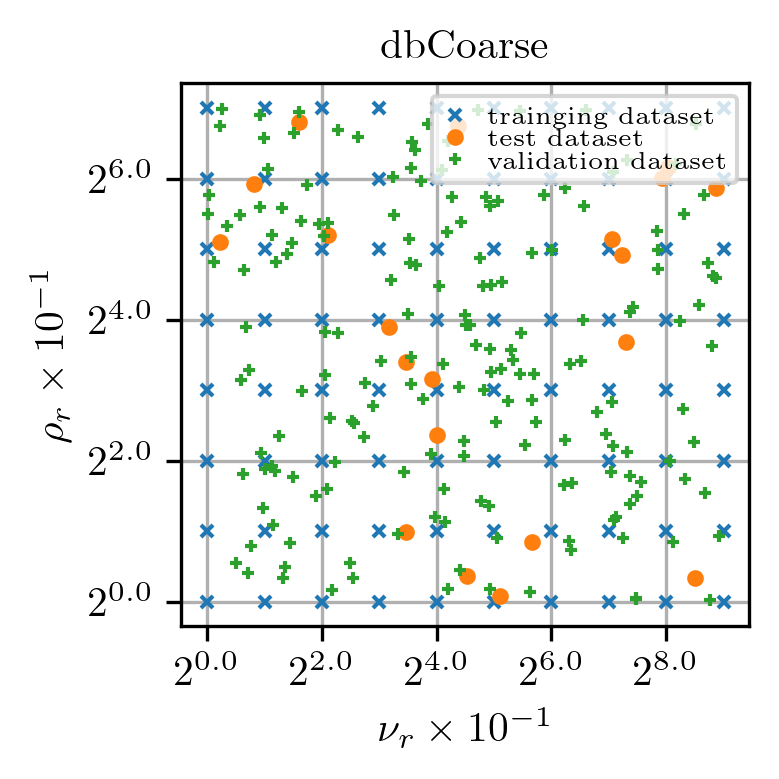

In [40]:
for ts in np.arange(0.05, 0.7, 0.05):
    print(ts)
    
    mu_test = np.load(pth_local_dbCoarseOLD+"t{:.2f}_mu_test.npy".format(ts))
    X_test = np.load(pth_local_dbCoarseOLD+"t{:.2f}_X_test.npy".format(ts))
    print(X_test.shape, mu_test.shape)
    
    mu_val = np.load(pth_local_dbCoarseOLD+"t{:.2f}_mu_val.npy".format(ts))
    X_val = np.load(pth_local_dbCoarseOLD+"t{:.2f}_X_val.npy".format(ts))
    print(X_val.shape, mu_val.shape)
    
    test_inside = ((nu_grid_c[0] <= mu_test[:, 0]) & (mu_test[:, 0] <= nu_grid_c[-1]) & 
                   (rho_grid_c[0] <= mu_test[:, 1]) & (mu_test[:, 1] <= rho_grid_c[-1]))
    mu_test = mu_test[test_inside, :]
    X_test = X_test[:, test_inside]
    print(X_test.shape, mu_test.shape)

    val_inside = ((nu_grid_c[0] <= mu_val[:, 0]) & (mu_val[:, 0] <= nu_grid_c[-1]) & 
                   (rho_grid_c[0] <= mu_val[:, 1]) & (mu_val[:, 1] <= rho_grid_c[-1]))
    mu_val = mu_val[val_inside, :]
    X_val = X_val[:, val_inside]
    print(X_val.shape, mu_val.shape)
    
    mu_testval = np.r_[mu_test, mu_val]
    X_testval = np.c_[X_test, X_val]
    
    n = 20
    mu_test = mu_testval[:20, :]
    mu_val = mu_testval[20:, :]
    X_test = X_testval[:, :20]
    X_val = X_testval[:, 20:]
    print(X_test.shape, mu_test.shape)
    print(X_val.shape, mu_val.shape)

    np.save(pth_local_dbCoarse+"t{:.2f}_mu_test.npy".format(ts), mu_test)
    np.save(pth_local_dbCoarse+"t{:.2f}_X_test.npy".format(ts), X_test)
    
    np.save(pth_local_dbCoarse+"t{:.2f}_mu_val.npy".format(ts), mu_val)
    np.save(pth_local_dbCoarse+"t{:.2f}_X_val.npy".format(ts), X_val)



fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/2))
nu_test, rho_test = np.split(mu_test, 2, axis=-1)
nu_val, rho_val = np.split(mu_val, 2, axis=-1)
plt.plot(nu_train_c, rho_train_c, lw=0.0, color='C0', marker='x', ms=3, label="trainging dataset")
plt.plot(nu_test, rho_test, lw=0.0, color='C1', marker='o', ms=3, label="test dataset")
plt.plot(nu_val, rho_val, lw=0.0, color='C2', marker='+', ms=3, label="validation dataset")

ax.set_xscale('log', base=2)
ax.set_yscale('log', base=2)
ax.xaxis.set_major_locator(ticker.FixedLocator(nu_grid_c))
ax.yaxis.set_major_locator(ticker.FixedLocator(rho_grid_c))
ax.set_xticklabels(nu_grid_c)
ax.set_yticklabels(rho_grid_c)

ax.set_xlabel(r'$\nu_r \times 10^{-1}$')
ax.set_ylabel(r'$\rho_r \times 10^{-1}$')
ax.set_xticks(nu_grid_c)
ax.set_yticks(rho_grid_c)
ax.set_xticklabels([r'$2^{'+'{:.1f}'.format(e)+'}$' for e in np.log2(ax.get_xticks()/10)])
ax.set_yticklabels([r'$2^{'+'{:.1f}'.format(e)+'}$' for e in np.log2(ax.get_yticks()/10)])
ax.set_xticks(ax.get_xticks()[::2])
ax.set_yticks(ax.get_yticks()[::2])
#ax.text(0.0, 1.01, r'$\times 10$') #, fontsize=10, transform = gca().transAxes)

ax.legend()
plt.grid(True)  # print(sgm, sz, ns)
plt.title("dbCoarse")
plt.savefig(pth_local_dbCoarse+"/db_datasets.pdf")
plt.show()

In [10]:
# the test and validation data are 200 simulations for random parameters (old), 84 new

# 1. locate files and parse nu and rho:
onlyfiles = [f for f in listdir(pth_server_dbFineVTU) if f.endswith(".series")]

nu_rand, rho_rand = np.array([]), np.array([])
for f in onlyfiles:
    m, r = re.findall(r"[-+]?\d*\.\d+|\d+", f)
    if not any(abs(float(m) - nu_grid_f)<1e-4) and not any(abs(float(r) - rho_grid_f)<1e-4):
        print(m, r, abs(float(m) - nu_grid_f), abs(float(r) - rho_grid_f))
        nu_rand = np.append(nu_rand, float(m))
        rho_rand = np.append(rho_rand, float(r))
print("found {:d} simulations for random parameters.".format(len(rho_rand)))
# 2. split into test and validation data
indices_shuffled = np.arange(len(nu_rand))
np.random.seed(0)
np.random.shuffle(indices_shuffled)
# indices_shuffled = np.array([  5, 101,  96, 169,  38, 150, 192,   8, 163,  54, 115,  42,  48,  75,  39, 132, 136,   9,  24,  92,
#                              108, 148,  76,  32, 134, 21,  83,   63, 128,  34,  65,  72,   4, 135,   2,  81, 107, 145, 167,   6,
#                              43, 20, 144, 182,  37, 113,  99,  44, 104, 176, 141, 112,  33, 121, 90, 102,  84, 156,  77,  89, 114, 15, 191, 158, 126,  71,
# 82,  35, 186,  80, 172,   7, 110,  10, 180,  26,  16, 168, 164, 94,  31, 120,  11,  47, 159, 196, 188, 174, 195, 161, 155, 198,
# 106, 119, 197,  52, 140, 131, 123, 117, 142, 183,  70, 105,  22, 138,  78, 199, 189, 179,  64, 130, 193,  98,  49, 143,  86, 185,
# 154,  93,  88, 152,  73, 100,  14,  85, 133, 184,  69,  28,  19,  1, 129, 122, 118,  50, 194,  59,  60, 157, 170, 171, 165, 178,
# 166,  51,  66,  13,  53, 187, 124,  12,  45,  57,  79,  27, 190, 18, 103, 151,  67,  97, 153, 116,  29, 162, 160,  36,  91, 181,
# 149, 127,  74, 146, 175,   3,  41, 111,  95,  62, 147,  56, 173, 17,  68, 139,  58,  55, 177, 109,   0,  23,  30, 125, 87, 46,  25, 137,  40,  61])

nu_test = nu_rand[indices_shuffled[:size_p_test]]
rho_test = rho_rand[indices_shuffled[:size_p_test]]
nu_val = nu_rand[indices_shuffled[size_p_test:]]
rho_val = rho_rand[indices_shuffled[size_p_test:]]

print(nu_rand)
print(nu_test)
print(nu_val)

111.0166 54.8346 [101.0166      96.87446438  91.0166      82.73232875  71.0166
  54.44805751  31.0166       2.12048499  48.9834     115.25756998
 208.9834     341.53173996 528.9834     794.08007992] [ 14.8346       7.2663154    1.73394249  12.43711322  25.1654
  40.3019692   58.30248499  79.70882644 105.1654     135.4385384
 171.43956998 214.25225288 265.1654     325.7116768  397.71373996
 483.33910576]
26.6021 55.0000 [ 16.6021      12.45996438   6.6021       1.68217125  13.3979
  29.96644249  53.3979      86.53498499 133.3979     199.67206998
 293.3979     425.94623996 613.3979     878.49457992] [ 15.           7.4317154    1.56854249  12.27171322  25.
  40.1365692   58.13708499  79.54342644 105.         135.2731384
 171.27416998 214.08685288 265.         325.5462768  397.54833996
 483.17370576]
842.9951 222.2064 [832.9951     828.85296438 822.9951     814.71082875 802.9951
 786.42655751 762.9951     729.85801501 682.9951     616.72093002
 522.9951     390.44676004 202.9951      62.1

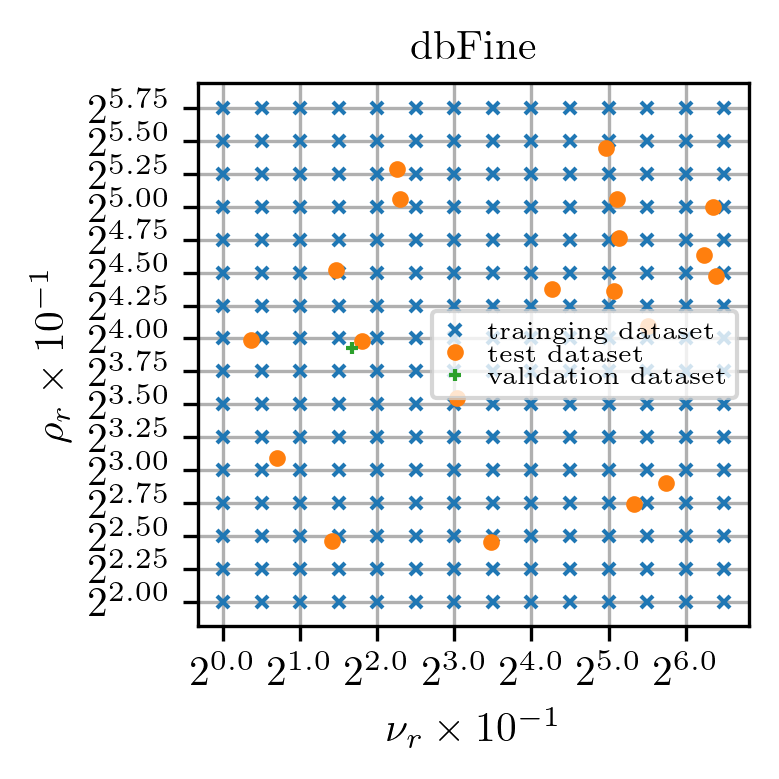

In [11]:
fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/2))
plt.plot(nu_train_f, rho_train_f, lw=0.0, color='C0', marker='x', ms=3, label="trainging dataset")
plt.plot(nu_test, rho_test, lw=0.0, color='C1', marker='o', ms=3, label="test dataset")
plt.plot(nu_val, rho_val, lw=0.0, color='C2', marker='+', ms=3, label="validation dataset")

ax.set_xscale('log', base=2)
ax.set_yscale('log', base=2)
ax.xaxis.set_major_locator(ticker.FixedLocator(nu_grid_f[::2]))
ax.yaxis.set_major_locator(ticker.FixedLocator(rho_grid_f))
ax.set_xticklabels(nu_grid_f[::2])
ax.set_yticklabels(rho_grid_f)

ax.set_xlabel(r'$\nu_r \times 10^{-1}$')
ax.set_ylabel(r'$\rho_r \times 10^{-1}$')
ax.set_xticks(nu_grid_f[::2])
ax.set_yticks(rho_grid_f)
ax.set_xticklabels([r'$2^{'+'{:.1f}'.format(e)+r'}$' for e in np.arange(0, 7, .5)[::2]])
ax.set_yticklabels([r'$2^{'+'{:.2f}'.format(e)+r'}$' for e in np.arange(2, 6, .25)])
#ax.text(0.0, 1.01, r'$\times 10$') #, fontsize=10, transform = gca().transAxes)

ax.legend()
plt.grid(True)  # print(sgm, sz, ns)
plt.title("dbFine")
plt.savefig(pth_local_dbFine+"/db_datasets.pdf")
plt.show()

In [11]:
# lets not re-load the data every time we change something...
if 'points' not in globals():
    u_train, p_train, points = get_data(pth_server_dbFineVTU, nu_train, rho_train, timesteps=[timestep])
    u_test, p_test, points = get_data(pth_server_dbFineVTU, nu_test, rho_test, timesteps=[timestep])
    u_val, p_val, _ = get_data(pth_server_dbFineVTU, nu_val, rho_val, timesteps=[timestep])

In [12]:
# pth = "C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/data/DamBreak/"
# for ts in np.arange(0.05, 0.7, 0.05):
#     print(ts)
#     u_train, p_train, points = get_data(mypath, nu_train, rho_train, timesteps=[ts])
#     np.save(pth+"t{:.2f}_mu_train.npy".format(ts), p_train)
#     np.save(pth+"t{:.2f}_X_train.npy".format(ts), u_train)
#     print(u_train.shape, p_train.shape, points.shape)
    
#     u_test, p_test, points = get_data(mypath, nu_test, rho_test, timesteps=[ts])
#     np.save(pth+"t{:.2f}_mu_test.npy".format(ts), p_test)
#     np.save(pth+"t{:.2f}_X_test.npy".format(ts), u_test)
#     print(u_test.shape, p_test.shape, points.shape)

#     u_val, p_val, _ = get_data(mypath, nu_val, rho_val, timesteps=[ts])
#     np.save(pth+"t{:.2f}_mu_val.npy".format(ts), p_val)
#     np.save(pth+"t{:.2f}_X_val.npy".format(ts), u_val)
#     print(u_val.shape, p_val.shape, _.shape)

#     np.save(pth+"points.npy", points)

In [13]:
# pth = "C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/data/damBreak_alpha/"
# np.savetxt(pth+"p_train.npy", p_train)
# np.savetxt(pth+"p_test.npy", p_test)
# np.savetxt(pth+"p_val.npy", p_val)
# np.savetxt(pth+"points.npy", points)
# #np.savetxt(pth+"X.npy", X)
# #np.savetxt(pth+"Y.npy", Y)

# np.savetxt(pth+"t{:.2f}_u_train.npy".format(timestep), u_train)
# np.savetxt(pth+"t{:.2f}_u_test.npy".format(timestep), u_test)
# np.savetxt(pth+"t{:.2f}_u_val.npy".format(timestep), u_val)

# #np.savetxt(pth+"t0.3_u_train_grd.npy", u_train_grid)
# #np.savetxt(pth+"t0.3_u_test_grd.npy", u_test_grid)
# #np.savetxt(pth+"t0.3_u_val_grd.npy", u_val_grid)

# # reg = RegularGrid()
# # pod = POD(rank=rank)
# # db = Database(p_train, u_train_grid.T)
# # rom = ROM(db, pod, reg)
# # rom.fit()
# # u_ROM_test = rom.predict(p_test).T
# # u_ROM_val = rom.predict(p_val).T
# # np.savetxt(pth+"t0.3_u_ROM_test_grd.npy", u_ROM_test)
# # np.savetxt(pth+"t0.3_u_ROM_val_grd.npy", u_ROM_val)

# pre processing: gridding

In [14]:
def threshold(data):
    data = data.copy()
    data[data < 0.5] = 0
    data[data >= 0.5] = 1
    return data

In [15]:
apply_threshold = True

In [16]:
#X, Y, test_snapshot = on_regular_grid(points,  u_train[:, 0])
#m, n = u_train.shape
n_x = n_y = 256
x = np.linspace(0, 0.584, n_x, endpoint=True)
y = np.linspace(0, 0.584, n_y, endpoint=True)
X, Y = np.meshgrid(x, y, indexing="ij")
is_wall = (0.292 <= X) & (X <= 0.316) & (Y <= 0.048)

u_train_grid = np.empty((n_x*n_y, u_train.shape[1]))
u_test_grid = np.empty((n_x*n_y, u_test.shape[1]))
u_val_grid = np.empty((n_x*n_y, u_val.shape[1]))

for u_set, u_set_grid in zip([u_train, u_test, u_val], [u_train_grid, u_test_grid, u_val_grid]):
    for j in range(u_set.shape[1]):
        gridded = griddata(points[:, :2], u_set[:, j], (X, Y), method="nearest")
        if apply_threshold:
            gridded = threshold(gridded)
        gridded[is_wall] = 0.5
        u_set_grid[:, j] = gridded.ravel()
gridded_shape = gridded.shape

# standard ROM

In [17]:
reg = RegularGrid()
pod = POD(rank=rank)
db = Database(p_train, u_train_grid.T)
rom = ROM(db, pod, reg)
rom.fit()
u_ROM = rom.predict(p_val).T
for j in range(len(p_val)):
    if apply_threshold:
        u_ROM[:, j] = threshold(u_ROM[:, j])
    rmw = u_ROM[:, j].reshape(gridded_shape)
    rmw[is_wall] = 0.5
    u_ROM[:, j] = rmw.ravel()

e_ROM = np.mean((u_ROM-u_val_grid)**2, axis=0)**.5

# smooth ROM, guessed parameters

In [18]:
sgm = 5.75
sz = 7
ns = 2

[28.1584 34.0925]


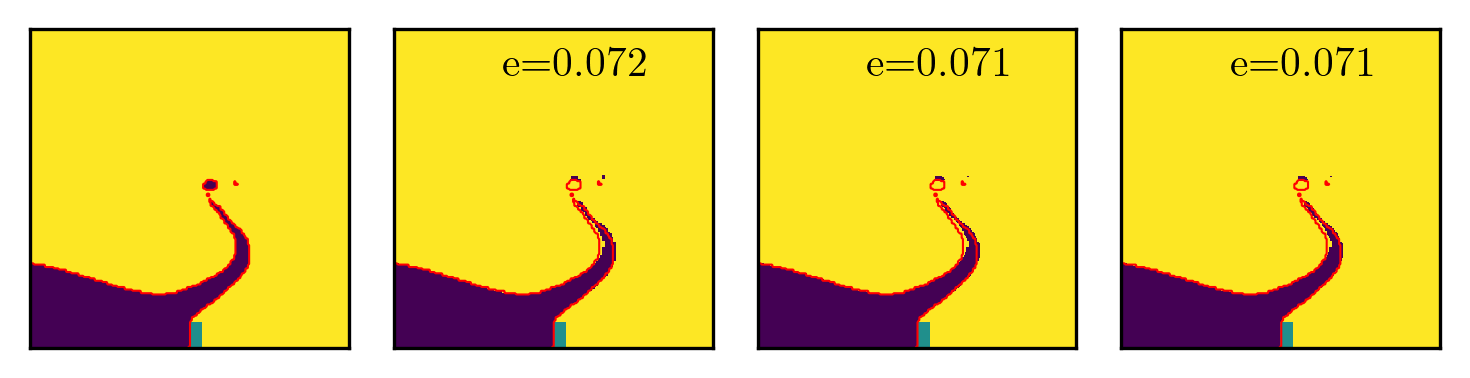

[41.3725 92.4209]


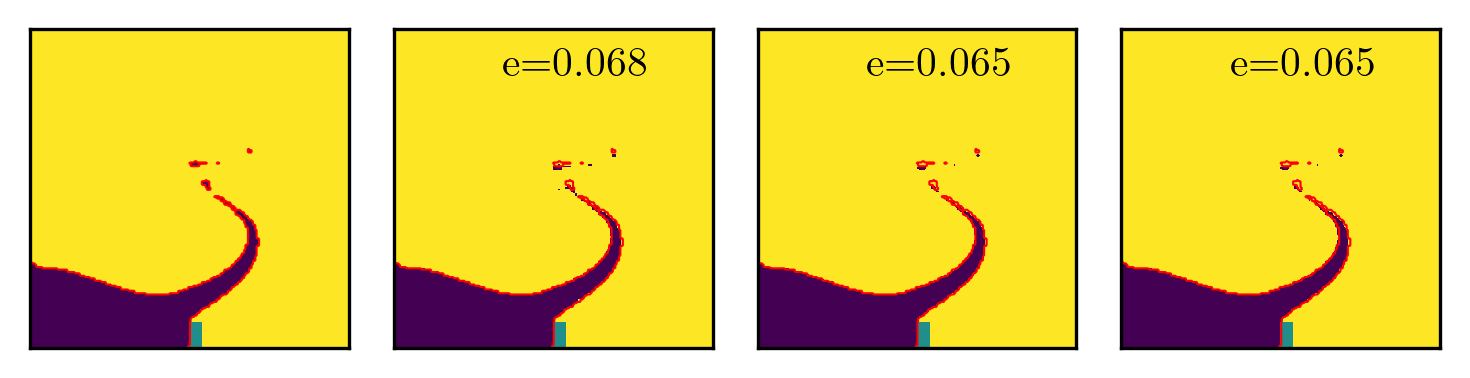

[208.5814  82.4122]


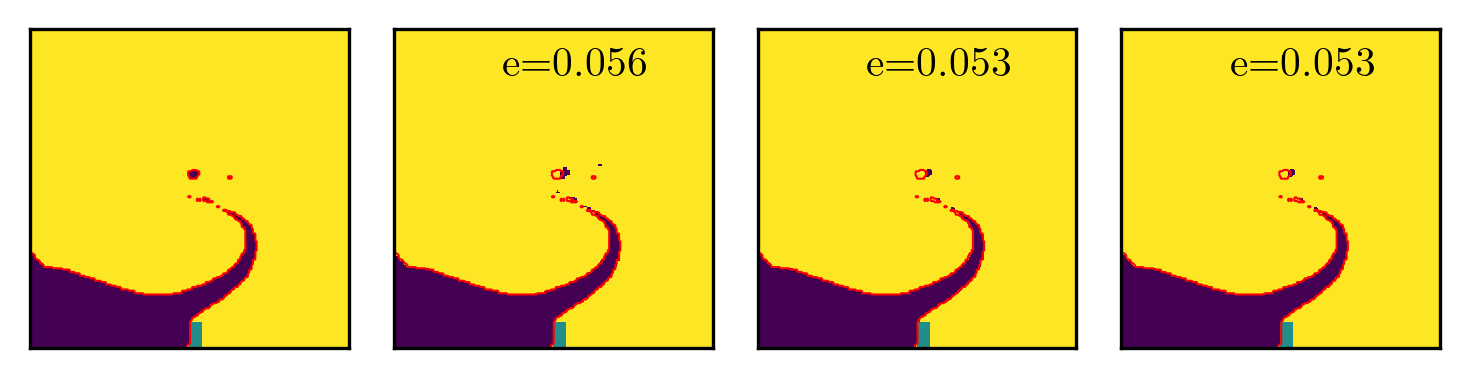

[ 14.8404 447.1545]


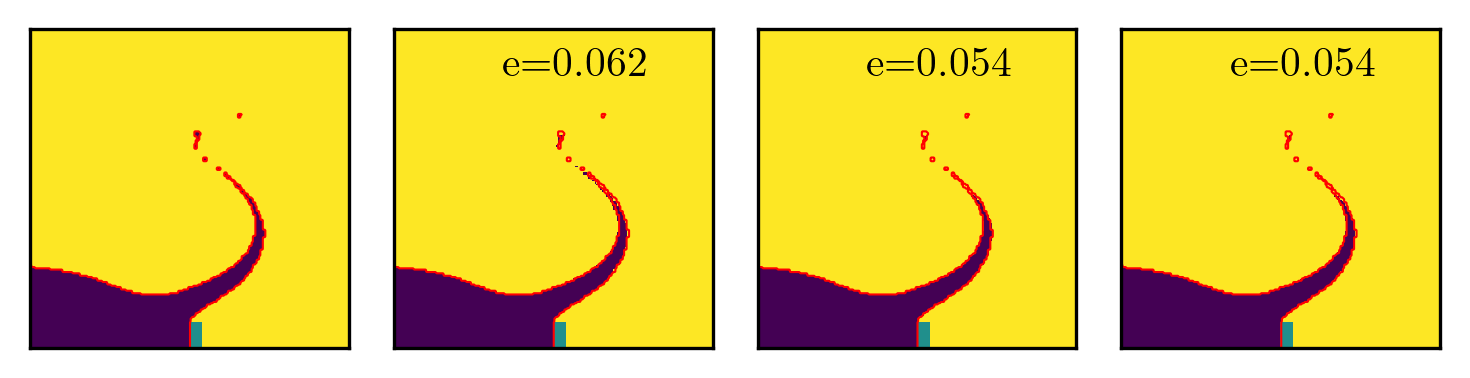

[352.0976 231.0398]


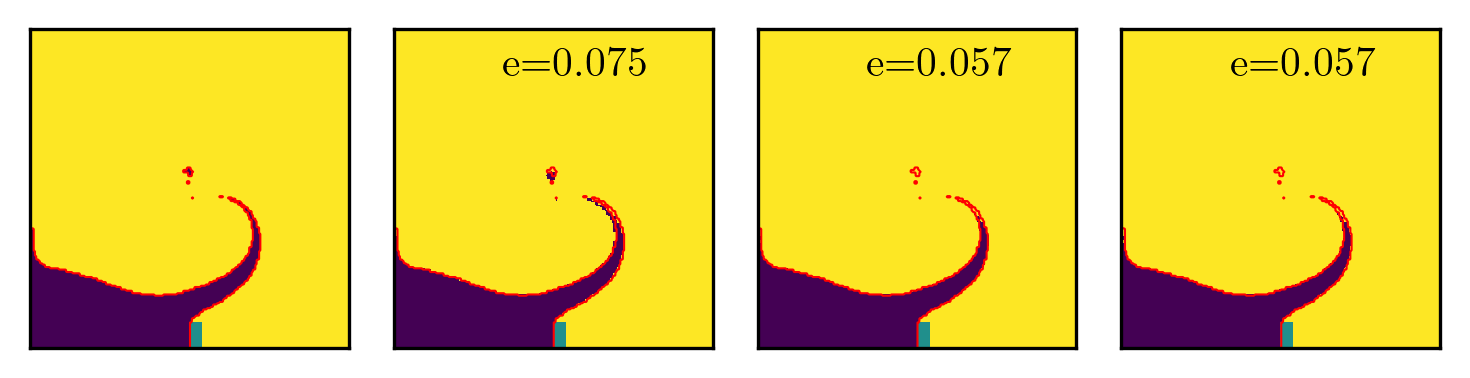

[124.3108 273.7841]


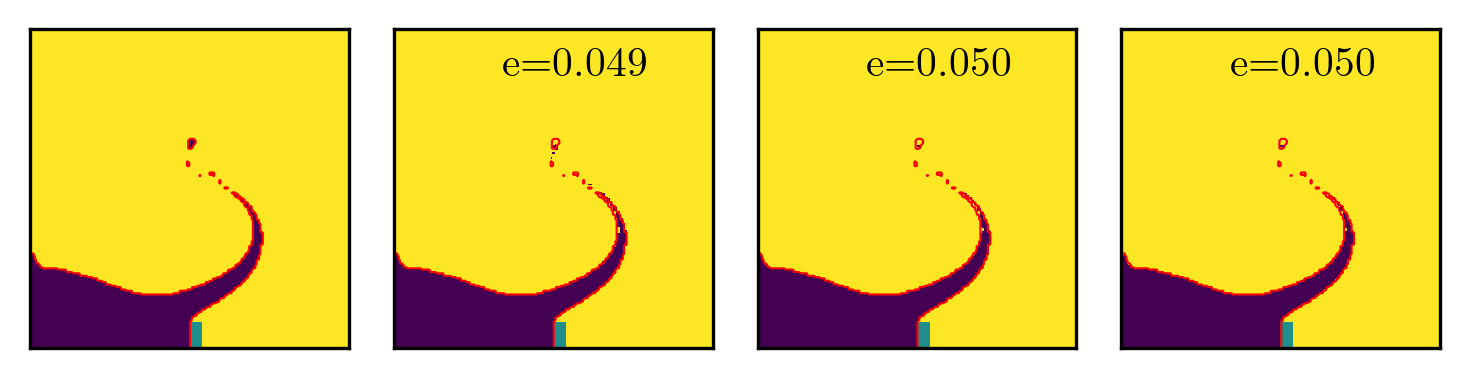

[ 22.9014 281.8679]


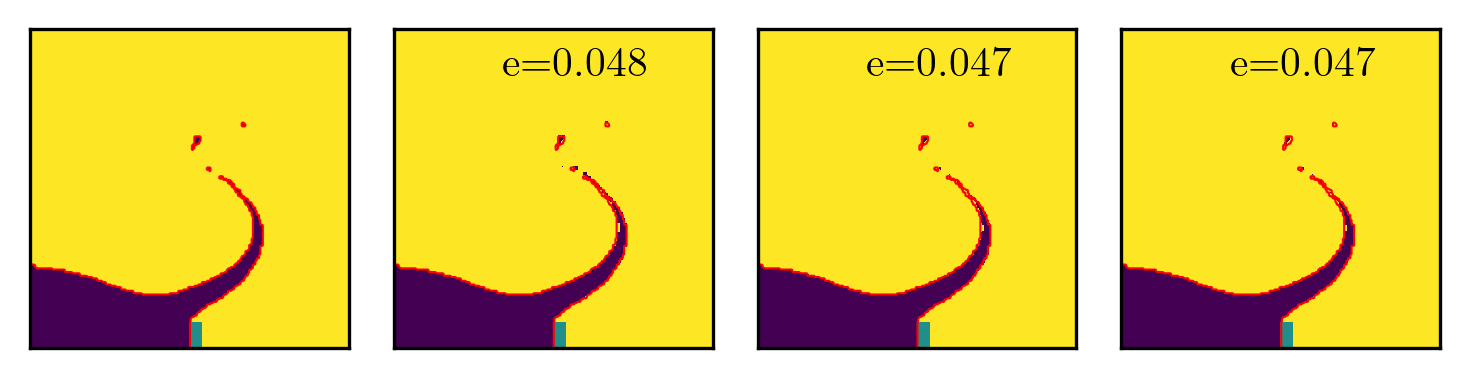

[180.2401 377.9266]


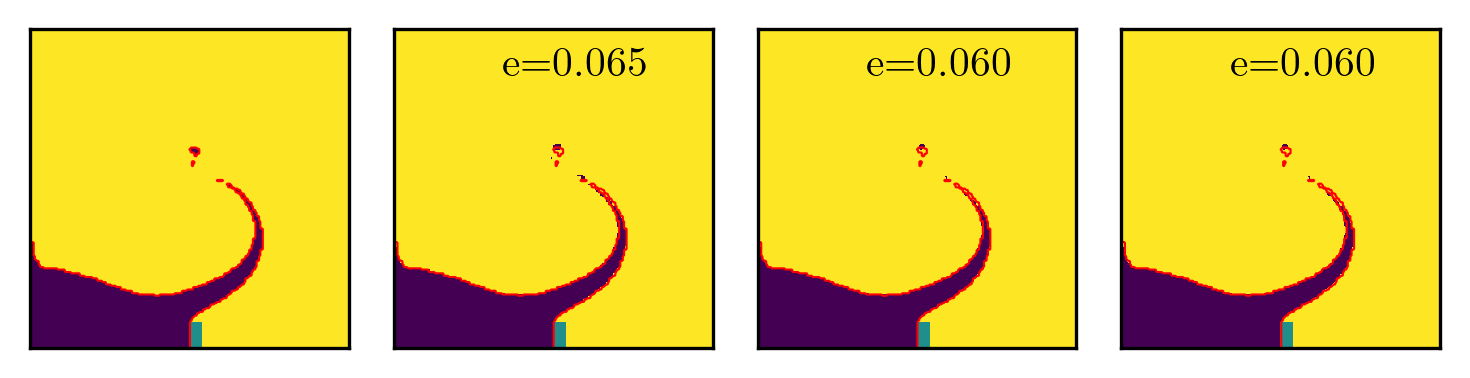

[328.9883  58.5261]


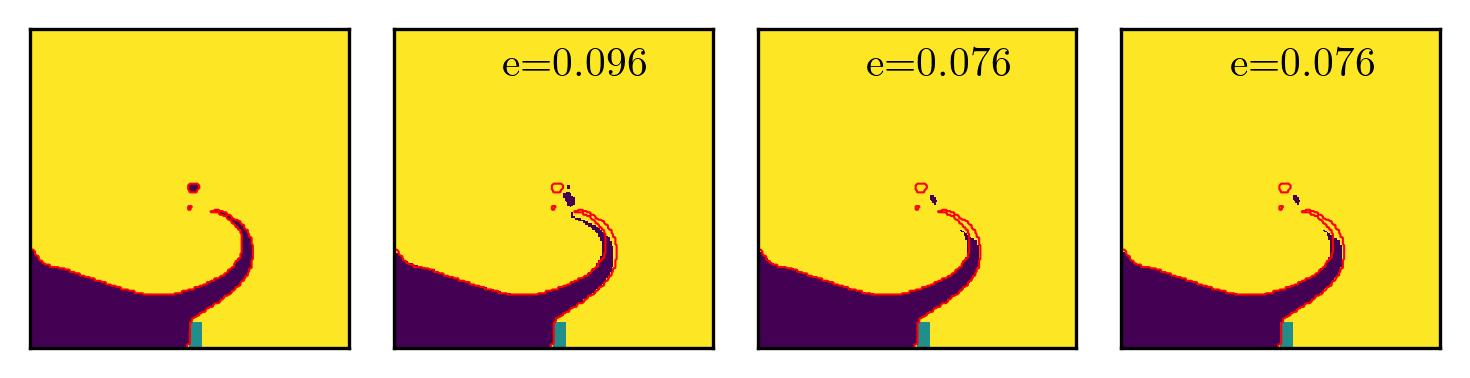

[148.662   42.8074]


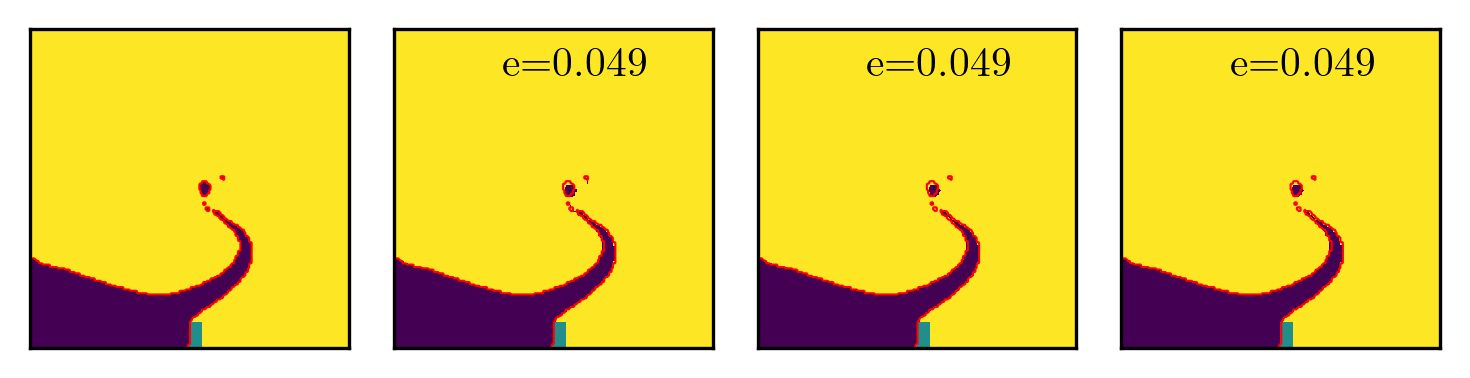

0.0641910926121513
0.0601502865705926
0.949432095378778
0.9370503620187052


In [28]:
u_train_smooth = np.zeros_like(u_train_grid)

for j in range(u_train_grid.shape[1]):
    ss2D = u_train_grid[:, j].reshape(gridded_shape)
    u_train_smooth[:, j] = gaussian_filter(ss2D, sigma=sgm, truncate=10).ravel()

reg = RegularGrid()
pod = POD(rank=rank)
db = Database(p_train, u_train_smooth.T)
rom = ROM(db, pod, reg)
rom.fit()

u_sROM = rom.predict(p_val).T


p_sharp = np.zeros_like(u_sROM)
for j in range(len(p_val)):
    p_sharp[:, j] = sharpen(u_sROM[:, j].copy().reshape(gridded_shape), sz, ns)
    if apply_threshold:
        p_sharp[:, j] = threshold(p_sharp[:, j])
    rmw = p_sharp[:, j].reshape(gridded_shape)
    rmw[is_wall] = 0.5
    p_sharp[:, j] = rmw.ravel()
    
    if apply_threshold:
        u_sROM[:, j] = threshold(u_sROM[:, j])
    rmw = u_sROM[:, j].reshape(gridded_shape)
    rmw[is_wall] = 0.5
    u_sROM[:, j] = rmw.ravel()
    if j < 10:
        print(p_val[j])
        fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(5, 15))
        cs1 = plot_dam_snapshot(ax1, u_val_grid[:, j].reshape(gridded_shape), X, Y)
        #plot_dam_snapshot(ax2, 1-u_sROM[:, j].reshape(gridded_shape), X, Y)
        #ax2.imshow(u_sROM[:, j].reshape(gridded_shape).T, origin="lower")
        cs2 = plot_dam_snapshot(ax2, u_ROM[:, j].reshape(gridded_shape), X, Y)
        cs3 = plot_dam_snapshot(ax3, u_sROM[:, j].reshape(gridded_shape), X, Y)
        cs4 = plot_dam_snapshot(ax4, p_sharp[:, j].reshape(gridded_shape), X, Y)

        ax2.text(0.2, 0.5, "e={:.3f}".format(np.mean((u_ROM[:, j]-u_val_grid[:, j])**2)**.5))
        ax3.text(0.2, 0.5, "e={:.3f}".format(np.mean((u_sROM[:, j]-u_val_grid[:, j])**2)**.5))
        ax4.text(0.2, 0.5, "e={:.3f}".format(np.mean((p_sharp[:, j]-u_val_grid[:, j])**2)**.5))
        
        ax1.contour(X, Y, u_val_grid[:, j].reshape(gridded_shape), levels=[0.5], linewidths=[0.5], colors=["r"])
        ax2.contour(X, Y, u_val_grid[:, j].reshape(gridded_shape), levels=[0.5], linewidths=[0.5], colors=["r"])
        ax3.contour(X, Y, u_val_grid[:, j].reshape(gridded_shape), levels=[0.5], linewidths=[0.5], colors=["r"])
        ax4.contour(X, Y, u_val_grid[:, j].reshape(gridded_shape), levels=[0.5], linewidths=[0.5], colors=["r"])
        
        for ax, cs in zip([ax1, ax2, ax3, ax4], [cs1, cs2, cs3, cs4]):
            ax.set_xticks([])
            ax.set_yticks([])
            #divider = make_axes_locatable(ax)
            #cax = divider.append_axes("right", size="5%", pad=0.05)
            #fig.colorbar(cs, cax=cax)
        plt.show()
eror_sROMs = np.mean((p_sharp-u_val_grid)**2, axis=0)**.5
print(np.mean(e_ROM))
print(np.mean(eror_sROMs))
print(np.mean(eror_sROMs/e_ROM))
print(np.mean(eror_sROMs)/np.mean(e_ROM))


# parameter optimization using test dataset

In [20]:
reg = RegularGrid()
pod = POD(rank=rank)
db = Database(p_train, u_train_grid.T)
rom = ROM(db, pod, reg)
rom.fit()
u_ROM = rom.predict(p_test).T
for j in range(len(p_test)):
    if apply_threshold:
        u_ROM[:, j] = threshold(u_ROM[:, j])
    rmw = u_ROM[:, j].reshape(gridded_shape)
    rmw[is_wall] = 0.5
    u_ROM[:, j] = rmw.ravel()

e_ROM = np.mean((u_ROM-u_test_grid)**2, axis=0)**.5
print(e_ROM.shape)

(20,)


In [21]:
u_train_smooth = np.zeros_like(u_train_grid)

sigmas = np.linspace(0, 7, 71)
n_sharpenings = [1, 2]
size_filter = [1, 3, 5, 7, 9]


e_sROMs = np.zeros((len(sigmas), len(size_filter), len(n_sharpenings), size_p_test))

for i, sgm in enumerate(sigmas):
   # print(i, end=", ")
    for j in range(u_train_grid.shape[1]):
        ss2D = u_train_grid[:, j].reshape(gridded_shape)
        u_train_smooth[:, j] = gaussian_filter(ss2D, sigma=sgm, truncate=10).ravel()

    reg = RegularGrid()
    pod = POD(rank=rank)
    db = Database(p_train, u_train_smooth.T)
    rom = ROM(db, pod, reg)
    rom.fit()

    u_sROM = rom.predict(p_test).T

    for k, sz in enumerate(size_filter):
        for l, ns in enumerate(n_sharpenings):
            p_sharp = np.zeros_like(u_test_grid)
            for j in range(len(p_test)):
                p_sharp[:, j] = sharpen(u_sROM[:, j].copy().reshape(gridded_shape), sz, ns)
                if apply_threshold:
                    p_sharp[:, j] = threshold(p_sharp[:, j])
                rmw = p_sharp[:, j].reshape(gridded_shape)
                rmw[is_wall] = 0.5
                p_sharp[:, j] = rmw.ravel()
            error_per_snapshot = np.mean((p_sharp-u_test_grid)**2, axis=0)**.5
            e_sROMs[i, k, l] = error_per_snapshot

size= 1 ns= 1 sigma_opt= 0.9 e= 0.05564668399346471
size= 1 ns= 2 sigma_opt= 0.9 e= 0.05564668399346471
size= 3 ns= 1 sigma_opt= 1.2000000000000002 e= 0.056513447419693316
size= 3 ns= 2 sigma_opt= 1.5 e= 0.05726686249871273
size= 5 ns= 1 sigma_opt= 2.4000000000000004 e= 0.05855260218745658
size= 5 ns= 2 sigma_opt= 3.6 e= 0.05924691073626935
size= 7 ns= 1 sigma_opt= 3.3000000000000003 e= 0.06024928053531253
size= 7 ns= 2 sigma_opt= 5.300000000000001 e= 0.06283720556391054
size= 9 ns= 1 sigma_opt= 4.1000000000000005 e= 0.06294337695585488
size= 9 ns= 2 sigma_opt= 7.0 e= 0.0682409109053544
0 0
0.9 1 1


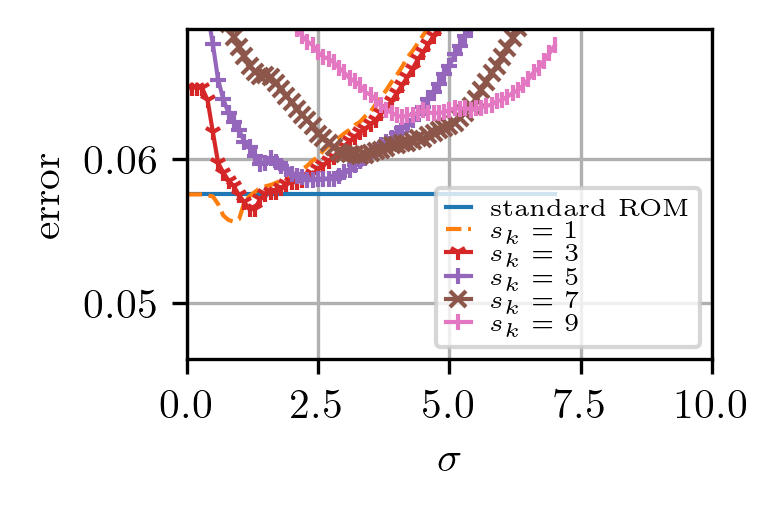

In [22]:
#plt.plot(sigmas, e2, label="smooth ROM")
fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
plt.plot(sigmas, np.ones_like(sigmas)*np.mean(e_ROM), lw=1, label="standard ROM")
colors = ["C2", "C3", "C4", "C5", "C6", "C7", "C8"]
marker = [".", "1", "+", "x", "|", "_", "0"]
plt.plot(sigmas, np.mean(e_sROMs[:, 0, 0], axis=1), "C1--", lw=1, label="$s_k=1$")
e_opt = 1e9
k_opt, l_opt = 1, 0
sgm = 0
for k, sz in enumerate(size_filter):
    #sz = size_filter[k]
    if k in [1, 2, 3, 4, 5]:
        plt.plot(sigmas, np.mean(e_sROMs[:, k, 0], axis=1), color=colors[k], marker=marker[k], ms=4, ls="-", lw=1, label="$s_k=${:2d}".format(sz))
       # plt.plot(sigmas, np.mean(e_sROMs[:, k, 0], axis=1), color=colors[k], marker="o", ms=3, ls="-", label="$n_s = ${:2d}$, sz=${:2d}".format(1, sz))
        #plt.plot(sigmas, np.mean(e_sROMs[:, k, 1], axis=1), color=colors[k], marker="X", ms=3, ls="--", label="$n_s = ${:2d}$, sz=${:2d}".format(2, sz))
        #plt.plot(sigmas, np.mean(e_sROMs[:, k, 2], axis=1), color=colors[k], marker="+", ms=3, ls=":", label="$n_s = ${:2d}$, sz=${:2d}".format(3, sz))
        # plt.plot(sigmas, np.max(e_sROMs[:, k, 0], axis=1), color=colors[k], marker="o", ms=3, ls="-", label="$n_s = ${:2d}$, sz=${:2d}".format(1, sz))
        # plt.plot(sigmas, np.min(e_sROMs[:, k, 1], axis=1), color=colors[k], marker="X", ms=3, ls="--", label="$n_s = ${:2d}$, sz=${:2d}".format(2, sz))
        # plt.plot(sigmas, np.min(e_sROMs[:, k, 2], axis=1), color=colors[k], marker="+", ms=3, ls=":", label="$n_s = ${:2d}$, sz=${:2d}".format(3, sz))
        
    for l, ns in enumerate(n_sharpenings):
        ind = np.argmin(np.mean(e_sROMs[:, k, l], axis=1))
        e = np.mean(e_sROMs[ind, k, l, :])
        print("size=", sz, "ns=", ns, "sigma_opt=", sigmas[ind], "e=", e)
        if e < e_opt:
            k_opt = k
            l_opt = l
            sgm = sigmas[ind]
            e_opt = e
plt.legend()
# plt.ylim([0.015, .025])
# plt.ylim([0.03, .04])
#plt.ylim([0.015, .02])
plt.ylim([np.min(np.mean(e_sROMs, axis=-1))*0.95, np.mean(e_ROM)*1.1])
plt.ylim([np.mean(e_ROM)*0.8, np.mean(e_ROM)*1.2])
plt.xlim([0, 10])
plt.xlabel("$\sigma$")
plt.ylabel("error")
plt.grid()

sz = size_filter[k_opt]
ns = n_sharpenings[l_opt]
print(k_opt, l_opt)
print(sgm, sz, ns)

# model valudation with optimized parameters and validation dataset

In [23]:
reg = RegularGrid()
pod = POD(rank=rank)
db = Database(p_train, u_train_grid.T)
rom = ROM(db, pod, reg)
rom.fit()
u_ROM = rom.predict(p_val).T
for j in range(len(p_val)):
    if apply_threshold:
        u_ROM[:, j] = threshold(u_ROM[:, j])
    rmw = u_ROM[:, j].reshape(gridded_shape)
    rmw[is_wall] = 0.5
    u_ROM[:, j] = rmw.ravel()

e_ROM = np.mean((u_ROM-u_val_grid)**2, axis=0)**.5
print(e_ROM.shape)

(180,)


In [24]:
for j in range(u_train_grid.shape[1]):
    ss2D = u_train_grid[:, j].reshape(gridded_shape)
    u_train_smooth[:, j] = gaussian_filter(ss2D, sigma=sgm, truncate=10).ravel()
reg = RegularGrid()
pod = POD(rank=rank)
db = Database(p_train, u_train_smooth.T)
rom = ROM(db, pod, reg)
rom.fit()
u_sROM = rom.predict(p_val).T

p_sharp = np.zeros_like(u_sROM)
for j in range(len(p_val)):
    p_sharp[:, j] = sharpen(u_sROM[:, j].copy().reshape(gridded_shape), sz, ns)
    if apply_threshold:
        p_sharp[:, j] = threshold(p_sharp[:, j])
    rmw = p_sharp[:, j].reshape(gridded_shape)
    rmw[is_wall] = 0.5
    p_sharp[:, j] = rmw.ravel()
eror_sROMs = np.mean((p_sharp-u_val_grid)**2, axis=0)**.5
print(e_ROM.shape, eror_sROMs.shape)
print(np.mean(e_ROM))
print(np.mean(eror_sROMs))
print("average relative error:", np.mean(eror_sROMs)/np.mean(e_ROM))
np.savetxt("C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/db_ROM_error_t{:.2f}_{:d}testss_sgm{:.1f}_sz{:d}_256x256.txt".format(timestep, size_p_test, sgm, sz),
          e_ROM)
np.savetxt("C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/db_sROMs_error_t{:.2f}_{:d}testss_sgm{:.1f}_sz{:d}_256x256.txt".format(timestep, size_p_test, sgm, sz),
          eror_sROMs)


(180,) (180,)
0.0641910926121513
0.0601502865705926
average relative error: 0.9370503620187052


## the model performs differently in different areas of the domain

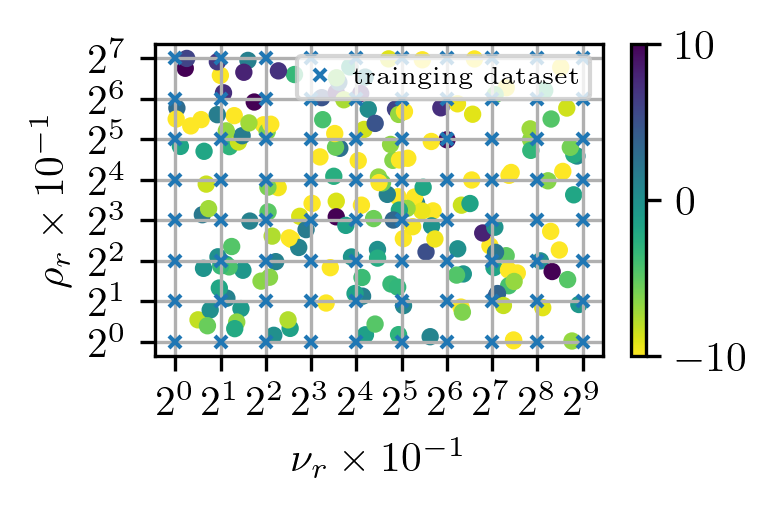

In [25]:
fig, ax = plt.subplots()
plt.plot(nu_train, rho_train, lw=0.0, color='C0', marker='x', ms=3, label="trainging dataset")


cs = plt.scatter(nu_val, rho_val, c=(eror_sROMs/e_ROM-1)*100, vmin=-10, vmax=10, s=10, cmap=cmap)
#plt.plot(nu_val, rho_val, lw=0.0, color='C2', marker='+', ms=3, label="validation dataset")

ax.set_xscale('log', base=2)
ax.set_yscale('log', base=2)
ax.xaxis.set_major_locator(ticker.FixedLocator(nu_grid))
ax.yaxis.set_major_locator(ticker.FixedLocator(rho_grid))
ax.set_xticklabels(nu_grid)
ax.set_yticklabels(rho_grid)

ax.set_xlabel(r'$\nu_r \times 10^{-1}$')
ax.set_ylabel(r'$\rho_r \times 10^{-1}$')
ax.set_xticks(nu_grid)
ax.set_yticks(rho_grid)
ax.set_xticklabels([r'$2^{:1d}$'.format(e) for e in np.arange(0, 10, 1)])
ax.set_yticklabels([r'$2^{:1d}$'.format(e) for e in np.arange(0, 8, 1)])
#ax.text(0.0, 1.01, r'$\times 10$') #, fontsize=10, transform = gca().transAxes)

ax.legend()
plt.grid(True)  # print(sgm, sz, ns)
plt.colorbar(cs)
name = "t{:.2f}_{:d}testss_sgm{:.1f}_sz{:d}_256x256.png".format(timestep, size_p_test, sgm, sz)
plt.savefig("C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/"+name)
plt.show()

In [26]:

print(np.mean(e_ROM))
print(np.mean(eror_sROMs))
print(np.mean(eror_sROMs/e_ROM))
print(np.mean(eror_sROMs)/np.mean(e_ROM))

0.0641910926121513
0.0601502865705926
0.949432095378778
0.9370503620187052


In [27]:
sgm, sz, ns = 2.3, 3, 1  # t=0.55
sgm, sz, ns = 0.9, 1, 1
